# Modelo 3 — Valor de Vida del Cliente (LTV) con Regresión Supervisada

**Modelos evaluados:** Linear Regression · Random Forest · Gradient Boosting

**Selección:** maximizar R²

**Criterios de éxito:**
- R² ≥ 0.70
- Minimización del MAE

## 1. Setup y paths

In [1]:
import sys
import os

PROJECT_ROOT = os.path.abspath('..')
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

DATA_PATH  = '../data-base/ecommerce_customer_churn_dataset.csv'
MODELS_DIR = '../models'
os.makedirs(MODELS_DIR, exist_ok=True)

## 2. Librerías

In [2]:
import pickle, warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split, RandomizedSearchCV, KFold
from sklearn.preprocessing import StandardScaler
from scipy.stats import randint, uniform
import importlib.util as _ilu
_spec=_ilu.spec_from_file_location('data_cleaning',
    os.path.join(PROJECT_ROOT,'src','dataMining','data_cleaning.py'))
_m=_ilu.module_from_spec(_spec); _spec.loader.exec_module(_m)
DataCleaner=_m.DataCleaner

## 3. Carga y limpieza de datos

[LOAD] 50,000 registros cargados desde '../data-base/ecommerce_customer_churn_dataset.csv'
[QUALITY] Edad > 100 eliminados → quedan 47,485 (removed 2,515)
[QUALITY] Duplicados eliminados → quedan 47,485 (removed 0)
[OUTLIERS] Sin compras eliminados → quedan 47,440 (removed 45)
[OUTLIERS] Cart abandonment > 100.0 eliminados → quedan 47,412 (removed 28)
[OUTLIERS] AOV outliers (IQR ×1.5) eliminados → quedan 46,467 (removed 945)
[IMPUTE] Sin nulos restantes ✓
Dataset limpio: 46,467 registros | 25 columnas
Target Lifetime_Value → media=$1407 | mediana=$1227 | min=$45 | max=$7078


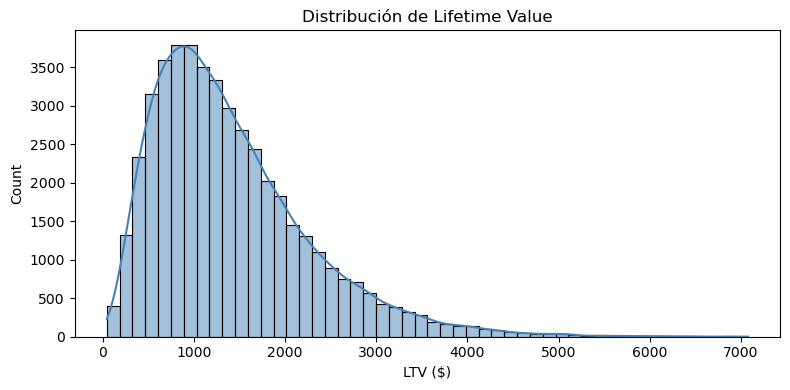

In [3]:
cleaner = DataCleaner(
    input_path=DATA_PATH,
    output_path=None,
    max_age=100,
    min_purchases=1,
    max_cart_rate=100.0,
    iqr_multiplier=1.5,
    impute_strategy='mean',
)
df = cleaner.run()
print(f'Dataset limpio: {df.shape[0]:,} registros | {df.shape[1]} columnas')

y_all = df['Lifetime_Value']
print(f'Target Lifetime_Value → media=${y_all.mean():.0f} | '
      f'mediana=${y_all.median():.0f} | min=${y_all.min():.0f} | max=${y_all.max():.0f}')

plt.figure(figsize=(8, 4))
sns.histplot(y_all, bins=50, kde=True, color='steelblue')
plt.title('Distribución de Lifetime Value')
plt.xlabel('LTV ($)')
plt.tight_layout()
plt.show()

## 4. Selección de features y split

In [4]:
FEATURES = [
    'Total_Purchases', 'Membership_Years', 'Discount_Usage_Rate',
    'Average_Order_Value', 'Login_Frequency', 'Session_Duration_Avg',
    'Pages_Per_Session', 'Returns_Rate', 'Email_Open_Rate',
]
FEATURES = [f for f in FEATURES if f in df.columns]
print(f'Features usadas ({len(FEATURES)}): {FEATURES}')

x = df[FEATURES]
y = df['Lifetime_Value']

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.20, random_state=42
)

scaler = StandardScaler()
x_train_sc = scaler.fit_transform(x_train)
x_test_sc  = scaler.transform(x_test)

print(f'Train: {x_train.shape[0]:,}  |  Test: {x_test.shape[0]:,}')

Features usadas (9): ['Total_Purchases', 'Membership_Years', 'Discount_Usage_Rate', 'Average_Order_Value', 'Login_Frequency', 'Session_Duration_Avg', 'Pages_Per_Session', 'Returns_Rate', 'Email_Open_Rate']
Train: 37,173  |  Test: 9,294


## 5. Entrenamiento y evaluación de regresores

In [5]:
cv = KFold(n_splits=3, shuffle=True, random_state=42)

param_spaces = {
    'Linear Regression': {
        'estimator': LinearRegression(),
        'needs_scale': True,
        'params': {},
    },
    'Random Forest': {
        'estimator': RandomForestRegressor(random_state=42, n_jobs=-1),
        'needs_scale': False,
        'params': {
            'n_estimators':    randint(100, 600),
            'max_depth':       randint(6, 25),
            'min_samples_leaf':randint(1, 10),
            'max_features':    ['sqrt', 'log2', 0.5, 0.7],
        },
    },
    'Gradient Boosting': {
        'estimator': GradientBoostingRegressor(random_state=42),
        'needs_scale': False,
        'params': {
            'n_estimators':    randint(100, 600),
            'max_depth':       randint(2, 8),
            'learning_rate':   uniform(0.01, 0.25),
            'subsample':       uniform(0.6, 0.4),
            'min_samples_leaf':randint(1, 10),
        },
    },
}

results = {}; best_name = ''; best_r2 = -np.inf
print(f'{"Modelo":<22} | {"R²":>7} | {"MAE":>10} | {"RMSE":>10} | Estado')
print('-' * 65)

for name, cfg in param_spaces.items():
    x_tr = x_train_sc if cfg['needs_scale'] else x_train
    x_te = x_test_sc  if cfg['needs_scale'] else x_test

    if cfg['params']:
        search = RandomizedSearchCV(
            cfg['estimator'], cfg['params'],
            n_iter=15, scoring='r2', cv=cv,
            n_jobs=-1, random_state=42, refit=True,
        )
        search.fit(x_tr, y_train)
        reg    = search.best_estimator_
        best_p = search.best_params_
    else:
        reg = cfg['estimator']
        reg.fit(x_tr, y_train)
        best_p = {}

    y_pred = reg.predict(x_te)
    r2   = r2_score(y_test, y_pred)
    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    status = '✓ CUMPLE' if r2 >= 0.70 else '⚠'
    print(f'{name:<22} | {r2:>7.4f} | {mae:>10.2f} | {rmse:>10.2f} | {status}')
    if best_p:
        print(f'  Best params: {best_p}')

    results[name] = dict(
        r2=round(r2,4), mae=round(mae,2), rmse=round(rmse,2),
        model=reg, needs_scale=cfg['needs_scale'],
        best_params=best_p, y_pred=y_pred,
    )
    if r2 > best_r2:
        best_r2 = r2; best_name = name

print(f'\n► Mejor modelo: {best_name} | R²={best_r2:.4f}')

Modelo                 |      R² |        MAE |       RMSE | Estado
-----------------------------------------------------------------
Linear Regression      |  0.7858 |     273.72 |     401.14 | ✓ CUMPLE


Random Forest          |  0.9311 |     157.56 |     227.54 | ✓ CUMPLE
  Best params: {'max_depth': 15, 'max_features': 0.7, 'min_samples_leaf': 3, 'n_estimators': 463}


Gradient Boosting      |  0.9412 |     150.46 |     210.24 | ✓ CUMPLE
  Best params: {'learning_rate': np.float64(0.12145818821339778), 'max_depth': 4, 'min_samples_leaf': 8, 'n_estimators': 472, 'subsample': np.float64(0.8404460046972835)}

► Mejor modelo: Gradient Boosting | R²=0.9412


## 6. Análisis del mejor modelo

Modelo: Gradient Boosting
R²  : 0.9412  ✓
MAE : $150.46
RMSE: $210.24


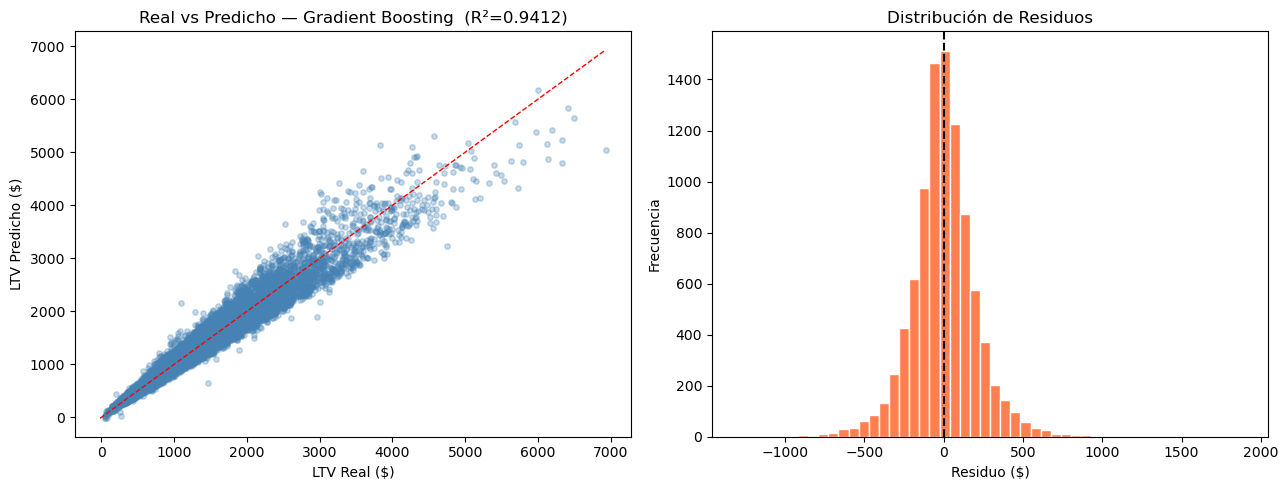

In [6]:
best = results[best_name]
y_pred_best = best['y_pred']

print(f'Modelo: {best_name}')
print(f'R²  : {best["r2"]:.4f}  {"✓" if best["r2"] >= 0.70 else "⚠"}')
print(f'MAE : ${best["mae"]:.2f}')
print(f'RMSE: ${best["rmse"]:.2f}')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Real vs Predicho
axes[0].scatter(y_test, y_pred_best, alpha=0.3, s=15, color='steelblue')
lims = [min(y_test.min(), y_pred_best.min()), max(y_test.max(), y_pred_best.max())]
axes[0].plot(lims, lims, 'r--', lw=1)
axes[0].set_xlabel('LTV Real ($)')
axes[0].set_ylabel('LTV Predicho ($)')
axes[0].set_title(f'Real vs Predicho — {best_name}  (R²={best["r2"]:.4f})')

# Distribución de residuos
residuals = np.array(y_test) - y_pred_best
axes[1].hist(residuals, bins=50, color='coral', edgecolor='white')
axes[1].axvline(0, color='black', linestyle='--')
axes[1].set_title('Distribución de Residuos')
axes[1].set_xlabel('Residuo ($)')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

## 7. Importancia de features

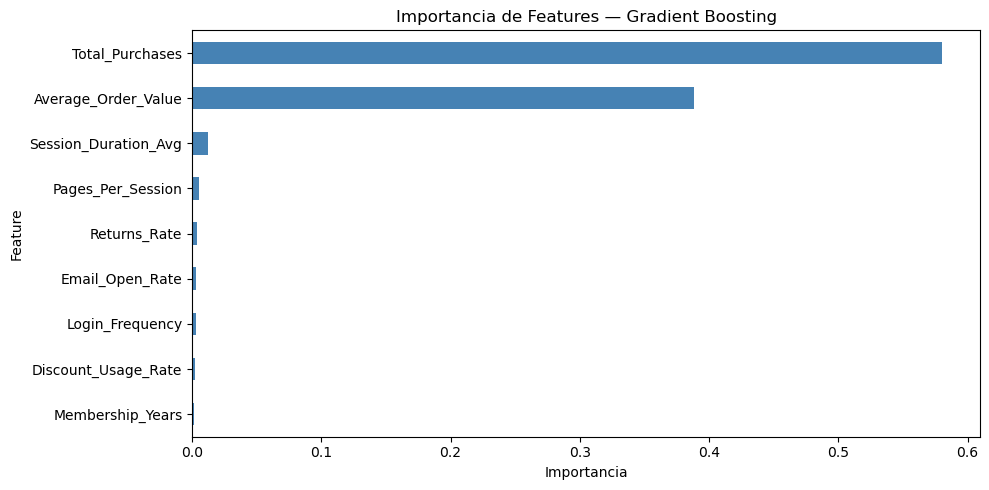

Top 5 predictores de LTV:
  Total_Purchases                     0.5806
  Average_Order_Value                 0.3883
  Session_Duration_Avg                0.0124
  Pages_Per_Session                   0.0053
  Returns_Rate                        0.0040


In [7]:
model = best['model']
feat_importance = {}

if hasattr(model, 'feature_importances_'):
    feat_importance = dict(sorted(
        zip(FEATURES, model.feature_importances_),
        key=lambda z: z[1], reverse=True
    ))
    fi_df = pd.DataFrame(feat_importance.items(), columns=['Feature', 'Importancia'])
    fi_df.plot(x='Feature', y='Importancia', kind='barh', figsize=(10, 5),
               color='steelblue', legend=False)
    plt.title(f'Importancia de Features — {best_name}')
    plt.xlabel('Importancia')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

    print('Top 5 predictores de LTV:')
    for feat, imp in list(feat_importance.items())[:5]:
        print(f'  {feat:<35} {imp:.4f}')
elif hasattr(model, 'coef_'):
    feat_importance = dict(zip(FEATURES, model.coef_))
    print('Coeficientes:', feat_importance)

## 8. Percentiles LTV para clasificación en tiers

In [8]:
# Predicción en todo el dataset para calcular percentiles reales
x_full = scaler.transform(df[FEATURES]) if best['needs_scale'] else df[FEATURES]
all_preds = model.predict(x_full)

P33 = float(np.percentile(all_preds, 33))
P66 = float(np.percentile(all_preds, 66))

print(f'Percentil 33 (umbral Bajo/Medio): ${P33:.2f}')
print(f'Percentil 66 (umbral Medio/Alto): ${P66:.2f}')

tiers = pd.cut(all_preds, bins=[-np.inf, P33, P66, np.inf], labels=['Bajo','Medio','Alto'])
tier_dist = pd.Series(tiers).value_counts(normalize=True) * 100
print('\nDistribución de LTV Tiers:')
print(tier_dist.round(1))

Percentil 33 (umbral Bajo/Medio): $932.05
Percentil 66 (umbral Medio/Alto): $1586.33

Distribución de LTV Tiers:
Alto     34.0
Bajo     33.0
Medio    33.0
Name: proportion, dtype: float64


## 9. Exportar modelo

Exporta el mejor regresor, el scaler y metadatos a `../models/ltv_model.pkl`.

In [9]:
ltv_bundle = {
    'model':              best['model'],
    'scaler':             scaler,
    'needs_scale':        best['needs_scale'],
    'features':           FEATURES,
    'model_name':         best_name,
    'r2':                 best['r2'],
    'mae':                best['mae'],
    'rmse':               best['rmse'],
    'p33':                P33,
    'p66':                P66,
    'best_params':        best.get('best_params', {}),
    'feature_importance': feat_importance,
    'all_results': {n:{'r2':v['r2'],'mae':v['mae'],'rmse':v['rmse']}
                    for n,v in results.items()},
}
out_path = os.path.join(MODELS_DIR, 'ltv_model.pkl')
with open(out_path, 'wb') as f: pickle.dump(ltv_bundle, f)
print(f'Modelo LTV exportado -> {out_path}')
print(f'  {best_name} | R²={best["r2"]:.4f} | MAE=${best["mae"]:.2f} | RMSE=${best["rmse"]:.2f}')
print(f'  Best params: {best.get("best_params", {})}')
print(f'  Tiers: Bajo<${P33:.0f} | Medio<${P66:.0f} | Alto>${P66:.0f}')

Modelo LTV exportado -> ../models/ltv_model.pkl
  Gradient Boosting | R²=0.9412 | MAE=$150.46 | RMSE=$210.24
  Best params: {'learning_rate': np.float64(0.12145818821339778), 'max_depth': 4, 'min_samples_leaf': 8, 'n_estimators': 472, 'subsample': np.float64(0.8404460046972835)}
  Tiers: Bajo<$932 | Medio<$1586 | Alto>$1586
